## Using Yi-Chao's 1/f noise generation code

In [1]:
import numpy as np
from meerKAT_sim.fnoise import fnoise
import matplotlib.pyplot as plt
print('If you want to avoid the HI_IM PY2 kernel you can just copy the functionality from the fnoise script -')
print('as it only needs numpy and scipy to run')

If you want to avoid the HI_IM PY2 kernel you can just copy the functionality from the fnoise script -
as it only needs numpy and scipy to run


In [2]:
#first you need to pick paramter values for the 1/f noise
print('The time correlated part of the power spectrum is propto (fk/f)^alpha.')
fknee = 0.001
alpha = 1.0
print('The frequency correlated part of the power spectrum is regulated by beta.')
print('beta=0 is 100 % correlated while beta = 1 is 0 % correlted - yes it really is that way round.')
beta = 0.2

The time correlated part of the power spectrum is propto (fk/f)^alpha.
The frequency correlated part of the power spectrum is regulated by beta.
beta=0 is 100 % correlated while beta = 1 is 0 % correlted - yes it really is that way round.


In [3]:
freq_spacing = 0.2 #spacing of frequency channels in MHz
int_time = 2. # data intergration time in seconds 
fclass = fnoise.FNoise(dtime=int_time, dfreq=freq_spacing, alpha=alpha, f0=fknee, beta=beta)

#a single gaussian realisation generated from the power spectrum set up in fclass
print('No white noise added (wn=False), just correlated noise.')
nch = 250 #set up number of frequencies
ntod = 2700 #set up number of time-ordered data samples
print('Note - you can define one frequency spacing in the power spectrum setup and use a different one for each realisation.')
print('this is in case you measure alpha, beta and fknee using data with spacing v1 but you want to simualte data with spacing v2')
# set the average to 1 so that we can multiply the data by this effective "gain"
rel = fclass.realisation(nch, ntod, freq_spacing, wn=False) + 1. 

No white noise added (wn=False), just correlated noise.
Note - you can define one frequency spacing in the power spectrum setup and use a different one for each realisation.
this is in case you measure alpha, beta and fknee using data with spacing v1 but you want to simualte data with spacing v2


(2700, 250)


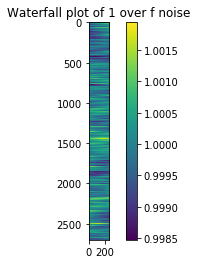

In [4]:
print(np.shape(rel))
plt.imshow(rel)
plt.colorbar()
plt.title('Waterfall plot of 1 over f noise')
plt.show()

/anaconda2/lib/python2.7/site-packages/matplotlib/cbook/deprecation.py:107: MatplotlibDeprecationWarning: Using pyplot.axes(ax) with ax an Axes argument is deprecated. Please use pyplot.sca(ax) instead.
  warnings.warn(message, mplDeprecation, stacklevel=1)


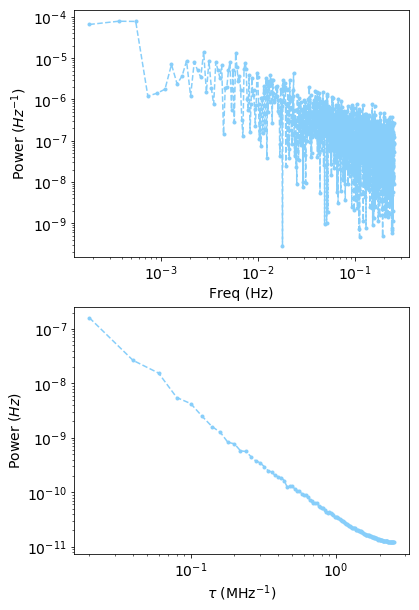

In [5]:
#Fourier tranform in 1D shows you that the noise is correlated (power spectra isn't flat like white noise should be)
fvals = np.fft.rfftfreq(ntod, d=int_time)
tpower = int_time * np.abs(np.fft.rfft(rel[:,0]))**2 / ntod

tvals = np.fft.rfftfreq(nch, d=freq_spacing)
fpower = freq_spacing * np.abs(np.fft.rfft(rel[0,:]))**2 / nch

fig, ((ax1, ax2)) = plt.subplots(nrows=2, ncols=1, figsize=(6, 10))
plt.axes(ax1)
plt.plot(fvals[1:], tpower[1:], color='lightskyblue', marker='.', linestyle = '--')
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='both', which='minor', labelsize=14)
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'Power ($Hz^{-1}$)', fontsize=14)
plt.xlabel('Freq (Hz)', fontsize=14)
plt.axes(ax2)
plt.plot(tvals[1:], fpower[1:], color='lightskyblue', marker='.', linestyle = '--')
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.tick_params(axis='both', which='minor', labelsize=14)
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'Power ($Hz$)', fontsize=14)
plt.xlabel(r'$\tau$ (MHz$^{-1}$)', fontsize=14)
plt.show()